In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("uber.csv")

In [3]:
df = df.drop(columns=["Unnamed: 0", "key"], errors="ignore")

In [4]:
df.dropna(inplace=True)

In [5]:
def haversine_distance(lat1, lon1, lat2, lon2):
  r = 6371  # Earth radius in km
  phi1, phi2 = np.radians(lat1), np.radians(lat2)
  dphi = np.radians(lat2 - lat1)
  dlambda = np.radians(lon2 - lon1)
  a = (
      np.sin(dphi / 2) ** 2
      + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
  )
  return 2 * r * np.arcsin(np.sqrt(a))


df["distance_km"] = haversine_distance(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"],
)

In [6]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek
df = df.drop(columns=["pickup_datetime"])

In [7]:
df = df[
    (df["fare_amount"] > 0)
    & (df["fare_amount"] <= 100)
    & (df["passenger_count"] > 0)
    & (df["passenger_count"] <= 6)
    & (df["distance_km"] > 0)
    & (df["distance_km"] <= 50)
    & (df["pickup_latitude"].between(-90, 90))
    & (df["dropoff_latitude"].between(-90, 90))
    & (df["pickup_longitude"].between(-180, 180))
    & (df["dropoff_longitude"].between(-180, 180))
]

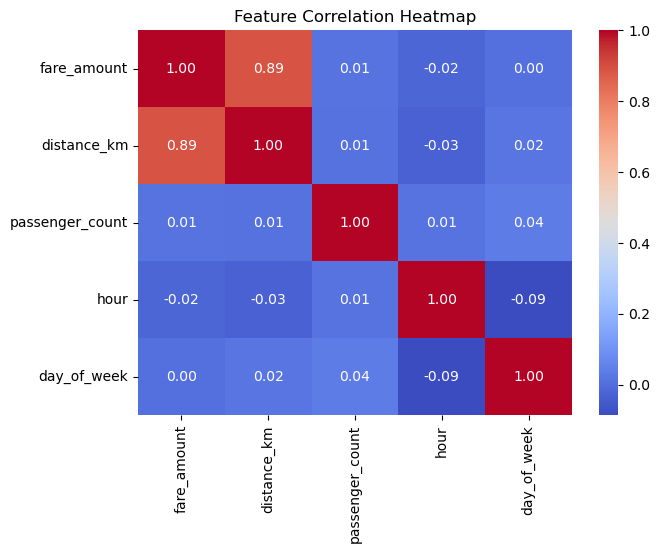

In [8]:
features = ["fare_amount", "distance_km", "passenger_count", "hour", "day_of_week"]
corr = df[features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
X = df[["distance_km", "passenger_count", "hour", "day_of_week"]]
y = df["fare_amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
}

In [10]:
results = []

for name, model in models.items():
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)

  r2 = r2_score(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))

  results.append({"Model": name, "R² Score": round(r2, 4), "RMSE": round(rmse, 4)})

results_df = pd.DataFrame(results)
print("\n--- Model Evaluation Summary ---")
print(results_df.to_string(index=False))


--- Model Evaluation Summary ---
            Model  R² Score   RMSE
Linear Regression    0.7706 4.5479
 Ridge Regression    0.7706 4.5479
 Lasso Regression    0.7706 4.5478
